# Lab 1: My First Neural Network (Diabetes Prediction)

## Preamble: What is this?
This is a Jupyter Notebook. It is like a physical notebook with text and images, but it also runs python scripts. We are hosting this notebook in the cloud on Google Colab. Later, if you are using Machine Learning algorithms in your own research you will probably run python scripts locally on your own computer, or perhaps even a super-computer. For learning however a notebook can be useful. It allows us to provide helpful information besides all the code. Running it on Google Colab allows us to get started without any installation burdens on your local device.

Keep in mind that when you are running code in Google Colab, you are running code in the cloud. Do not process private data in Google Colab!

In  a notebook there are two types of fields, a text field (in markdown) like this one. And a code field, with python code, like the one below here. Python is a programming language like R. It can run algorithms and do calculations. You can run a code cell using the play button (or ctrl+enter).

In [205]:
1 + 1 

2

Python also comes with many add-ons, prefabricated libraries of code, known as modules. These modules make doing complex things simple. We can import them using `import`

In [206]:
# for example the datetime module provides a bunch of code to work with dates and times
import datetime
datetime.date.today() + datetime.timedelta(days=7)  # this makes time arithmetic easy!

datetime.date(2026, 3, 30)

Throughout this course we will be working with a bunch of famous machine learning modules, let's import them now. We will get into what they all do later, once we use them.

In [207]:
import numpy, pandas, torch, sklearn, matplotlib.pyplot as plt

We've also abstracted some code into the background. Run the cell below to set up Colab in such a way to be able to check your answers.

In [208]:
import os
if not os.path.exists('/content/ML4Epidemiology'):
    !git clone https://github.com/SimonIlic/ML4Epidemiology.git
%cd /content/ML4Epidemiology/Lesson1

fatal: destination path 'ML4Epidemiology' already exists and is not an empty directory.
[Errno 2] No such file or directory: '/content/ML4Epidemiology/Lesson1'
/Users/ilic/Documents/ML4Epidemiology/Lesson1


## Assignment: Predicting Diabetes

For this class we will be training a neural network to predict diabetes based on factors like blood pressure, insulin and glucose levels. In order to train a model and make predictions, first we will need some data. We need data both to train a model, training data, and to test its performance, test data.

In this notebook we will be using the [Pima Indians Diabetes Dataset](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database). This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

The datasets consist of several medical predictor variables and one target variable, Outcome. Predictor variables include the number of pregnancies the patient has had, their BMI, insulin level, age, and so on.

### Loading and Exploring the dataset
Let's load the dataset from the web. See if you can make sense from these lines of code

In [209]:
# the dataset is as a Comma Seperated Values (csv) file hosted on GitHub at this URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
# we declare the column names since the csv file does not have a header row
headers = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DPF', 'Age', 'Diabetes']
# we use pandas to read the csv file into a DataFrame, which is a tabular data structure with rows and columns
dataset = pandas.read_csv(url, names=headers)
dataset.head()  # df.head() shows the first 5 rows of the dataset

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


We have now loaded our dataset as a [Pandas](https://pandas.pydata.org/) Dataframe. A dataframe is like a table, but more dynamic and malleable. We can do things like sorting and filtering the table, just like in Excel.

In [210]:
# sort by age
dataset.sort_values(by='Age')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Diabetes
255,1,113,64,35,0,33.6,0.543,21,1
60,2,84,0,0,0,0.0,0.304,21,0
102,0,125,96,0,0,22.5,0.262,21,0
182,1,0,74,20,23,27.7,0.299,21,0
623,0,94,70,27,115,43.5,0.347,21,0
...,...,...,...,...,...,...,...,...,...
123,5,132,80,0,0,26.8,0.186,69,0
684,5,136,82,0,0,0.0,0.640,69,0
666,4,145,82,18,0,32.5,0.235,70,1
453,2,119,0,0,0,19.6,0.832,72,0


In [211]:
# filter rows where glucose > 120
dataset[dataset['Glucose'] > 120]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DPF,Age,Diabetes
0,6,148,72,35,0,33.6,0.627,50,1
2,8,183,64,0,0,23.3,0.672,32,1
4,0,137,40,35,168,43.1,2.288,33,1
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1
...,...,...,...,...,...,...,...,...,...
759,6,190,92,0,0,35.5,0.278,66,1
761,9,170,74,31,0,44.0,0.403,43,1
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0


In [212]:
# we can also get some stats
mean_insulin = dataset.Insulin.mean()  # mean insulin level
max_bmi = dataset.BMI.max()  # max BMI
print(f"Mean insulin level: {mean_insulin}, Max BMI: {max_bmi}")

Mean insulin level: 79.79947916666667, Max BMI: 67.1


### Exercise 1: Make yourself familiar with the datset.
a) To get yourself familiar with the dataset let's explore the dataframe a bit. For each column write down what it signifies, including units. You will have to look this up online.

* Pregnancies: Total number of times pregnant (#)
* Glucose: Plasma glucose concentration (2-hour OGTT) (mg/dL)
* BloodPressure: <span style="color:red">Diastolic blood pressure (mm Hg)</span>
* SkinThickness: <span style="color:red">Triceps skin fold thickness (mm)</span>
* Insulin: <span style="color:red">2-hour serum insulin (mu U/ml</span>
* BMI: <span style="color:red">Body mass index (kg/m^2)</span>
* DPF: <span style="color:red">Diabetes Pedigree function (unitless)</span>
* Age: <span style="color:red">Age (years)</span>
* Diabetes: <span style="color:red">Diabeters (True (1), False (0))</span>

b) Explore the dataset to answer the following questions:
1. What is the maximum number of pregnancies a woman endured in the dataset?
2. What is the mean age of the individuals in the dataset?
3. How many people have diabetes?


In [213]:
#Free Code Field for exercise 1


In [214]:
# insert your answers to 1b) here
max_pregnancies = dataset.Pregnancies.max()
mean_age = dataset.Age.mean()
num_diabetes = dataset.Diabetes.sum()  # we can sum the Diabetes column since it is binary (0 for false and 1 for true)

If you like you can check your answers using this line of code:

In [215]:
# this line of code is obfuscated by design, no need to understand it, just run it to check your answers
import answers; assert max_pregnancies == answers.max_pregnancies, "Something is wrong with your answer for max_pregnancies"; numpy.testing.assert_approx_equal(mean_age, answers.mean_age); assert num_diabetes == answers.num_diabetes, "Something is wrong with your answer for num_diabetes"; print("All answers are correct!")

All answers are correct!


Let's inspect our data through histograms. Run the line below to display 9 histograms.

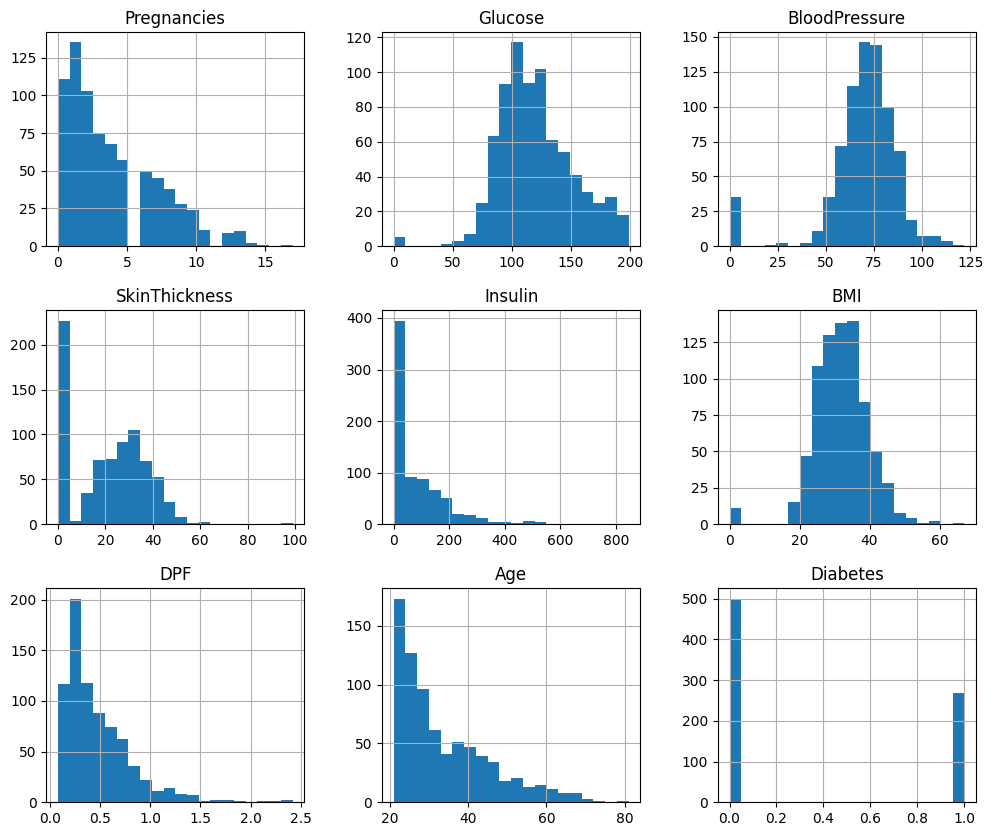

In [216]:
dataset.hist(figsize=(12, 10), bins=20); plt.show()

### Data Preparation
Based on what you know now about the dataset, what columns should be the features X, and what column should be the target y?

In [217]:
feature_columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DPF", "Age"]
target_column = "Diabetes"
X = dataset.drop(columns=target_column).values
y = dataset[target_column].values

As we learned in class we need to split our data into a development (train, validation) and unseen test set. 

![](imgs/train_validation_test.jpg)

In [218]:
from sklearn.model_selection import train_test_split
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.1)

It is important that data is normalized before running any deep learning model fitting. Neural Networks prefer standard normal data. For this we will use a rescaler.

In [219]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [220]:
X_train = torch.FloatTensor(scaler.fit_transform(X_train))
X_val = torch.FloatTensor(scaler.transform(X_val))
X_test = torch.FloatTensor(scaler.transform(X_test))
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_val = torch.FloatTensor(y_val).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)

Let's plot that data again. What do you notice? What happened to the 9th histogram? Did all our normalization operations succeed? What are the spikes we see? If you want you can take some time to improve your data pre-processing pipeline and use these plots to check their effect. Once you feel ready, move on.

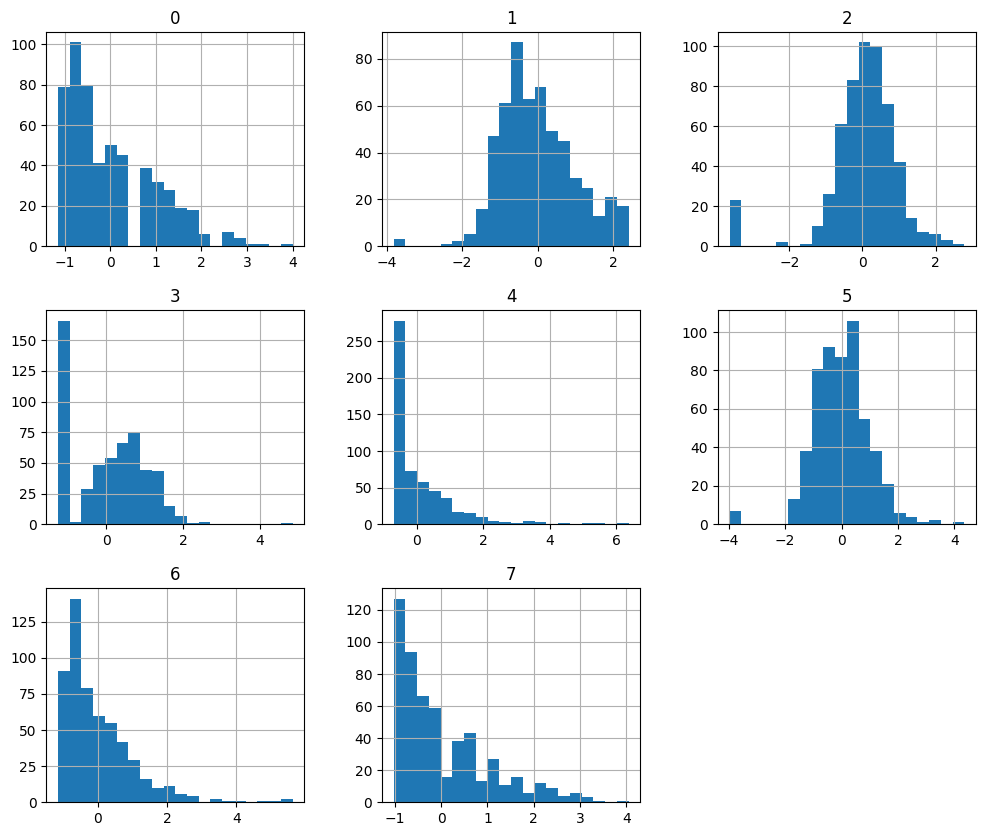

In [221]:
# plot histograms
pandas.DataFrame(X_train).hist(figsize=(12, 10), bins=20); plt.show()

<span style="color:red">We should notice a few things now. Some columns look well normalized, some do not. Columns 1, 2 and 5 look fine. The others do not look very normally distributed. Going back to the original histograms we can see why. There are two separate causes. Some columns have missing data imputed as 0 (SkinThickness and Insulin), other columns are simply not normally distributed (Age, Pregnancies and PDF). Let's tackle those issues one by one.</span>

<span style="color:red">We will perform our transformations on a fresh copy of the dataset</span>

In [222]:
dataset_copy = dataset.copy()

<span style="color:red">There are several ways to deal with data imputation. We will simply ignore the zero values, just for rescaling the data, and leave the training and test data as is.</span>

In [223]:
# set values where insulin is zero to None (missing value)
insulin_filter = (dataset_copy.Insulin == 0.0)
dataset_copy.loc[insulin_filter, 'Insulin'] = None
# do the same for SkinThickness in one go
dataset_copy.loc[dataset_copy['SkinThickness'] == 0, 'SkinThickness'] = None

<span style="color:red">For the Age, Pregnancies and PDF columns we will assume they are distributed according to a [Poisson distribution](https://en.wikipedia.org/wiki/Poisson_distribution). A common strategy to deal with normalizing this kind of distribution is to take the square root or the log of the column. We will use log.</span>

In [224]:
dataset_copy.Age = numpy.log(dataset_copy.Age)
dataset_copy.Pregnancies = numpy.log(dataset_copy.Pregnancies + 1)  # add 1 to avoid log(0)
dataset_copy.DPF = numpy.log(dataset_copy.DPF + 1)

<span style="color:red">Let's look at the data again.<span>

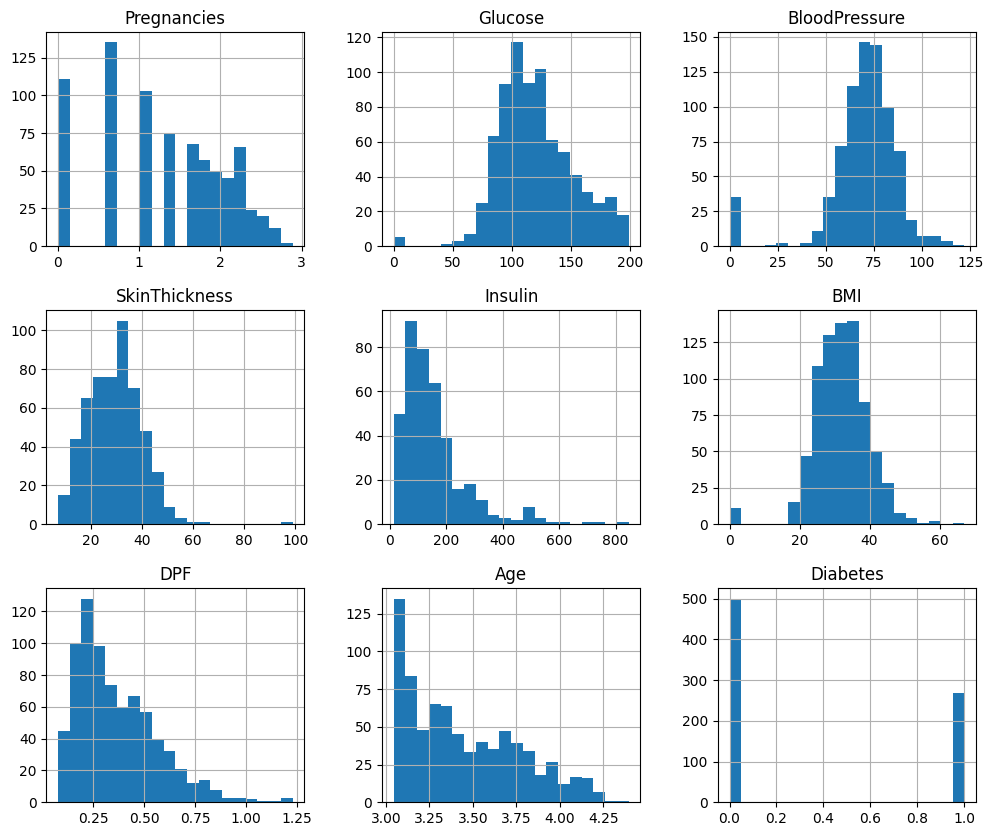

In [225]:
dataset_copy.hist(figsize=(12, 10), bins=20); plt.show()

<span style="color:red">That looks a lot better. Now re-apply our data transforms. One more thing. We only want to ignore the zero data for scaling, but not in our network. So first we fit the scaler, then re-enter zero, then apply the transform.</span>

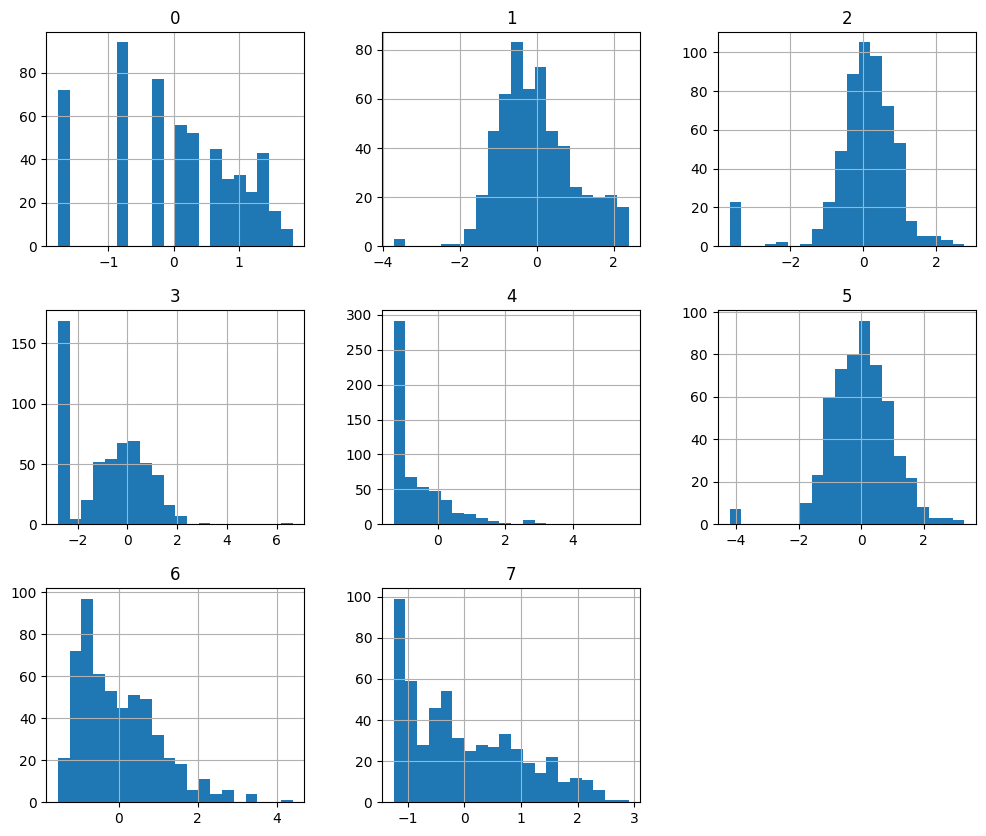

In [226]:
feature_columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DPF", "Age"]
target_column = "Diabetes"
X = dataset_copy.drop(columns=target_column).values
y = dataset_copy[target_column].values
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.2)
X_train, X_val, y_train, y_val = train_test_split(X_dev, y_dev, test_size=0.1)
scaler = StandardScaler()
scaler.fit_transform(X_train)

# re-enter zero values
X_train = numpy.nan_to_num(X_train)
X_val = numpy.nan_to_num(X_val)
X_test = numpy.nan_to_num(X_test)

# scale data
X_train = torch.FloatTensor(scaler.transform(X_train))
X_val = torch.FloatTensor(scaler.transform(X_val))
X_test = torch.FloatTensor(scaler.transform(X_test))
y_train = torch.FloatTensor(y_train).view(-1, 1)
y_val = torch.FloatTensor(y_val).view(-1, 1)
y_test = torch.FloatTensor(y_test).view(-1, 1)
# plot histograms
pandas.DataFrame(X_train).hist(figsize=(12, 10), bins=20); plt.show()

### The Neural Network

Let's get to the heart of this notebook: We are going to build a model to make predictions: The Multi-Layer Perceptron. This is a fancy term for a standard feed-forward neural network.


![](imgs/neural_network.jpg)

Think of a neural network like a committee of doctors looking at a patient's chart:

1.  **Input Layer:** These are the numbers on the chart (Glucose, Age, BMI, etc.). We have 8 charts (features), so our input layer needs 8 nodes.
2.  **Hidden Layer:** These are the junior doctors. They look at combinations of the inputs to find patterns (e.g., "High age + High BMI" might be a specific risk factor). We will use **12 neurons** here. Why 12? It's a design choice; enough to learn patterns, but not so big that it memorizes the data.
3.  **Activation Function (ReLU):** This introduces non-linearity. Without it, the network is just a linear regression line. It decides if a neuron "fires" or stays silent.
4.  **Output Layer:** This is the head doctor. They take the insights from the junior doctors and make a final recommendation: How confident are we the patient has diabetes? 
5.  **Output Activation (Sigmoid):** This squashes the final number into a probability between 0 and 1.

![](imgs/activation_function.jpg)

In [227]:
import torch
import torch.nn.functional as F

# Example input tensor (can include negative, zero, positive values)
x = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])

print("Input:")
print(x)

# Apply Sigmoid
sigmoid_output = torch.sigmoid(x)
print("\nAfter Sigmoid:")
print(sigmoid_output)

# Apply ReLU
relu_output = F.relu(x)
print("\nAfter ReLU:")
print(relu_output)

Input:
tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])

After Sigmoid:
tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])

After ReLU:
tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])


We will build our model using the PyTorch module. PyTorch is an open-source machine learning framework for building and training neural networks using Python. It behaves very similar to NumPy, making models easy to write, debug, and experiment with. PyTorch is widely used in both research and production systems and integrates tightly with GPUs and modern deep learning tooling.

In [228]:
import torch.nn as nn

class DiabetesClassifier(nn.Module):
    def __init__(self, input_dim, n_hidden, output_dim):
        super(DiabetesClassifier, self).__init__()
        # these are all the building blocks of our network
        self.hidden_layer = nn.Linear(input_dim, n_hidden) 
        self.relu = nn.ReLU()
        self.output = nn.Linear(n_hidden, output_dim)
        self.sigmoid = nn.Sigmoid()

    # the forward function defines in what order the building blocks are applied to the input data
    def forward(self, x):
        activations = self.relu(self.hidden_layer(x))
        output = self.sigmoid(self.output(activations))
        return output

Now that we have defined our model architecture. Let's build it. Defining our model requires 3 parameters: The input dimension, number of hidden neurons and output dimension. Some of these are set by the data we are dealing with, some are free design choices. Based on what you learned in class try to draw out the neural network we defined above. What are the number of input nodes, hidden nodes and output nodes?

In [229]:
input_dim = 8
n_hidden = 16  # this is a free hyperparameter, you can change it to whatever you see fit
output_dim = 1

model = neural_network = DiabetesClassifier(input_dim, n_hidden, output_dim)

To test you understanding of the model, how many configurable parameters (or weights) does this model have?

In [230]:
total_number_of_parameters = 8 * 16 + 16 + 16 * 1 + 1

<span style="color:red">Input x Number of output neurons + bias for every layer</span>

Check you answer by running the cell below

In [231]:
assert total_number_of_parameters == answers.num_of_parameters(model)

We now have a model, but it is currently "dumb"—it has not learned anything yet. To train it, we need two things:

1.  **Criterion (Loss Function):** A way to measure how wrong the model is at the current training step. Since we are doing binary classification (0 or 1), we use **Binary Cross Entropy (BCELoss)**. If the model predicts 0.9 (Diabetes) but the true answer is 0 (No Diabetes), the Loss will be high. If the model predicts 0.1 and the true answer is 0, the loss will be low.

![](imgs/BCE.jpg)

Disease present (true = 1)
- The penalty is small when the model predicts high probability of disease.
- The penalty becomes very large if the model predicts near 0 (confidently wrong).

Disease absent (true = 0)
- The penalty is small when the model predicts low probability of disease.
- The penalty becomes very large if the model predicts near 1.

2.  **Optimizer:** A way to update the model to make it less wrong next time. We will use **Adam**, a very popular optimizer that adjusts the learning rate automatically.

In [232]:
import torch.optim as optim
criterion = nn.BCELoss() # Binary Cross Entropy
optimizer = optim.Adam(model.parameters(), lr=0.01)

### The Training Process

This is where the magic happens. We will force the model to look at the data 100 times (100 **Epochs**). In every single epoch, the following steps happen:

1.  **Forward Pass:** The model makes a guess based on it's current weights.
2.  **Calculate Loss:** We check how wrong that guess was compared to `y_train`.
3.  **Backward Pass (Backpropagation):** We calculate which weights contributed to the error.
4.  **Step:** The optimizer nudges the weights in the opposite direction of the error to improve accuracy.

In [233]:
# we will keep track of the loss, so we can plot it later
losses = []
eval_losses = []


for epoch in range(40):
    # ---- Training ----
    # try to understand what each line does
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)  # forward pass
    loss = criterion(outputs, y_train)  # compute the loss
    loss.backward()  # backpropagation
    optimizer.step()  # update the parameters
    losses.append(loss.item())

    # ---- Validation ----
    # note we do not train on this samples only compute the loss
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        eval_losses.append(val_loss.item())

Take your time now to play around with the free hyperparameters, and see how they adjust our training dynamics. Make sure to re-run the entire notebook after you adjust something using the Run All button up above. Keep an eye on the training and validation loss using the code below.

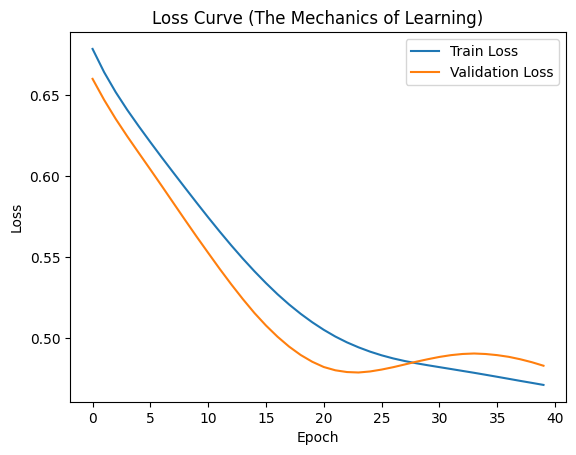

In [234]:
# You don't have to understand all the code below
plt.plot(losses, label='Train Loss')
plt.plot(eval_losses, label='Validation Loss')
plt.title("Loss Curve (The Mechanics of Learning)")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

<span style="color:red">Using the figure from the lectures, you should gauge the "sweet spot" of low training loss and no offerfitting. In our case this is around 40 epochs.</span>

Remember you would like to avoid overfitting, so that your model generalizes to unseen data. 

![](imgs/overfitting.jpg)

## Prediction
Now that we have trained our model, let's make some predictions! Play around with this datapoint and see how to model's predictions change based on the input.

In [235]:
# we should apply the same transformations to the input data as we did to the training data, in this case log transformation for pregnancies, dpf and age
pregnancies = numpy.log(3 + 1)
glucose = 80
blood_pressure = 70
skin_thickness = 20
insulin = 79.0
bmi = 32.0
dpf = numpy.log(0.5 + 1)
age = numpy.log(21)

patient_info = torch.FloatTensor([pregnancies, glucose, blood_pressure, skin_thickness, insulin, bmi, dpf, age])
# don't forget to scale the datapoint!
patient_info = scaler.transform(patient_info.view(1, -1))

prediction = model(torch.FloatTensor(patient_info)).item()
print(prediction)


0.07113125920295715


The model has been trained! But how well does it diagnose patients it has never seen before? We held back `X_test` for this exact moment.

We need to:
1. Turn off the gradient calculation (we aren't training anymore, just testing).
2. Pass the test data through the model.
3. Round the results (since the model outputs a probability like 0.78, we round it to 1 for Diabetes).

In [236]:
# make predictions
with torch.no_grad():
    
    test_set_predictions = model(X_test).round()
    test_accuracy = sum(test_set_predictions == y_test) / len(y_test)

    train_set_predictions = model(X_train).round()
    train_accuracy = sum(train_set_predictions == y_train) / len(y_train)
    print(f"Train Accuracy: {train_accuracy.item():.2f}")
    print(f"Test Accuracy: {test_accuracy.item():.2f}")


Train Accuracy: 0.77
Test Accuracy: 0.84


Let's also look at the confusion matrix.

In [237]:
from sklearn.metrics import confusion_matrix
y_pred = test_set_predictions.numpy()
cm = confusion_matrix(y_test, y_pred)
cm_df = pandas.DataFrame(cm, index=["True Negative", "True Positive"], columns=["Predicted Negative", "Predicted Positive"])
cm_df

,Predicted Negative,Predicted Positive
True Negative,97,8
True Positive,17,32


## Conclusion
You have successfully built, trained, and evaluated your first neural network! An accuracy around 75-80% is typical for this dataset with a simple model. 

**To explore further:**
1. Try changing the number of neurons in the hidden layer (from 12 to 32 or 64).
2. Try adding a third layer to the network class.
3. In the training loop, keep track of the loss on the validation set and see what you can learn from this.
4. Try training for more epochs (e.g., 500) and see if the accuracy improves or gets worse (overfitting).
5. Compare the performance of the neural network with other statistical models you are already familiar with, e.g. logistic regression.

You might like to explore [Sklearn](https://scikit-learn.org/stable/index.html)
This is python package with many traditional ML models that is easy to use out of the box (see example below).

In [239]:
from sklearn import svm
from sklearn.metrics import accuracy_score

svm_model = svm.SVC()
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)  # class labels

test_acc = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", test_acc)

SVM Accuracy: 0.7987012987012987


/Users/ilic/.venvs/.research/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [245]:
from sklearn.linear_model import LogisticRegression

logreg_model = LogisticRegression(max_iter=1000)

logreg_model.fit(X_train, y_train)
y_pred_logreg = logreg_model.predict(X_test)

test_acc_logreg = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", test_acc_logreg)

Logistic Regression Accuracy: 0.8246753246753247


/Users/ilic/.venvs/.research/lib/python3.11/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/ilic/.venvs/.research/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ilic/.venvs/.research/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ilic/.venvs/.research/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/ilic/.venvs/.research/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encount